# BIC

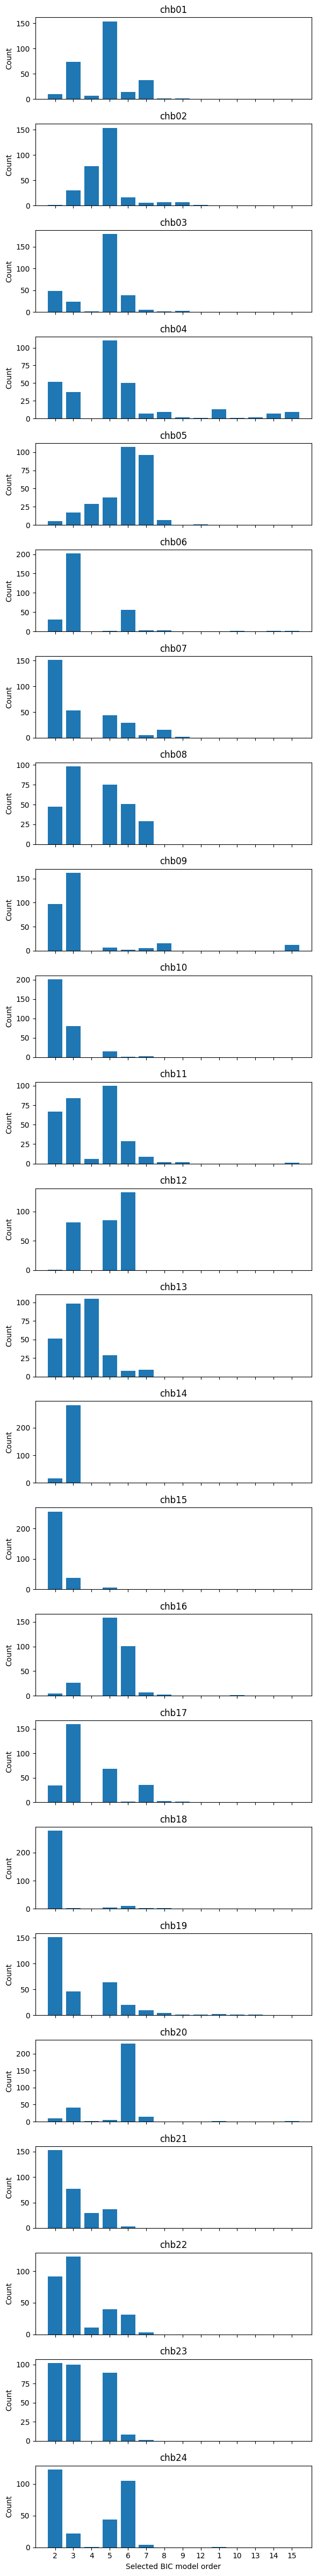

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("var_order_all.csv")   # Change to your filename

# Get patients
patients = sorted(df["patient"].unique())

# Create one subplot per patient
fig, axes = plt.subplots(
    nrows=len(patients),
    figsize=(6, 2*len(patients)),
    sharex=True
)

# Handle case with only one patient
if len(patients) == 1:
    axes = [axes]

for ax, patient in zip(axes, patients):
    orders = df[df["patient"] == patient]["order"]

    counts = orders.value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(patient)
    ax.set_ylabel("Count")

axes[-1].set_xlabel("Selected BIC model order")

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
df = pd.DataFrame({
    "Patient": range(1, 25),
    "VAR Order": [5, 5, 5, 5, 6, 3, 2, 5, 3, 2, 3, 5,
                  4, 3, 2, 5, 3, 2, 2, 6, 2, 3, 3, 5]
})

print(df)



    Patient  VAR Order
0         1          5
1         2          5
2         3          5
3         4          5
4         5          6
5         6          3
6         7          2
7         8          5
8         9          3
9        10          2
10       11          3
11       12          5
12       13          4
13       14          3
14       15          2
15       16          5
16       17          3
17       18          2
18       19          2
19       20          6
20       21          2
21       22          3
22       23          3
23       24          5


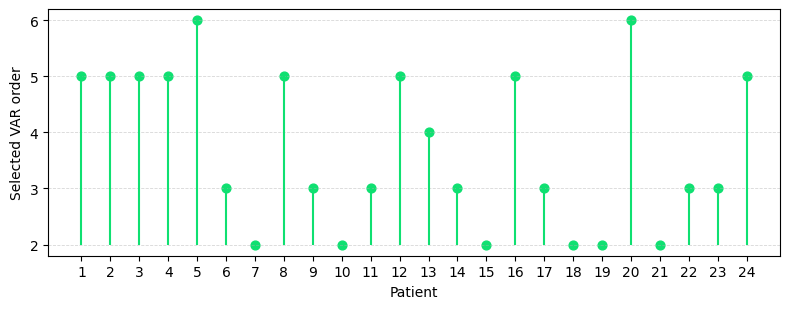

In [27]:
import matplotlib.pyplot as plt

color = "#0fe071"

plt.figure(figsize=(8, 3.2))

plt.vlines(df["Patient"], 2, df["VAR Order"],
           linewidth=1.5, color=color)
plt.scatter(df["Patient"], df["VAR Order"],
            s=40, color=color)

plt.xticks(df["Patient"])
plt.yticks(range(2, 7))
plt.ylim(1.8, 6.2)

plt.xlabel("Patient")
plt.ylabel("Selected VAR order")

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd

summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Standard deviation",
        "Median",
        "Minimum",
        "Maximum"
    ],
    "Correlation": [
        fres_comparison_results["correlation"].mean(),
        fres_comparison_results["correlation"].std(),
        fres_comparison_results["correlation"].median(),
        fres_comparison_results["correlation"].min(),
        fres_comparison_results["correlation"].max()
    ],
    "MAE": [
        fres_comparison_results["mae"].mean(),
        fres_comparison_results["mae"].std(),
        fres_comparison_results["mae"].median(),
        fres_comparison_results["mae"].min(),
        fres_comparison_results["mae"].max()
    ]
})

# Format as decimals
summary["Correlation"] = summary["Correlation"].map(lambda x: f"{x:.6f}")
summary["MAE"] = summary["MAE"].map(lambda x: f"{x:.8f}")

print(summary)

            Statistic Correlation         MAE
0                Mean    0.999985  0.00001442
1  Standard deviation    0.000040  0.00000952
2              Median    0.999995  0.00001308
3             Minimum    0.999566  0.00000000
4             Maximum    1.000000  0.00004662


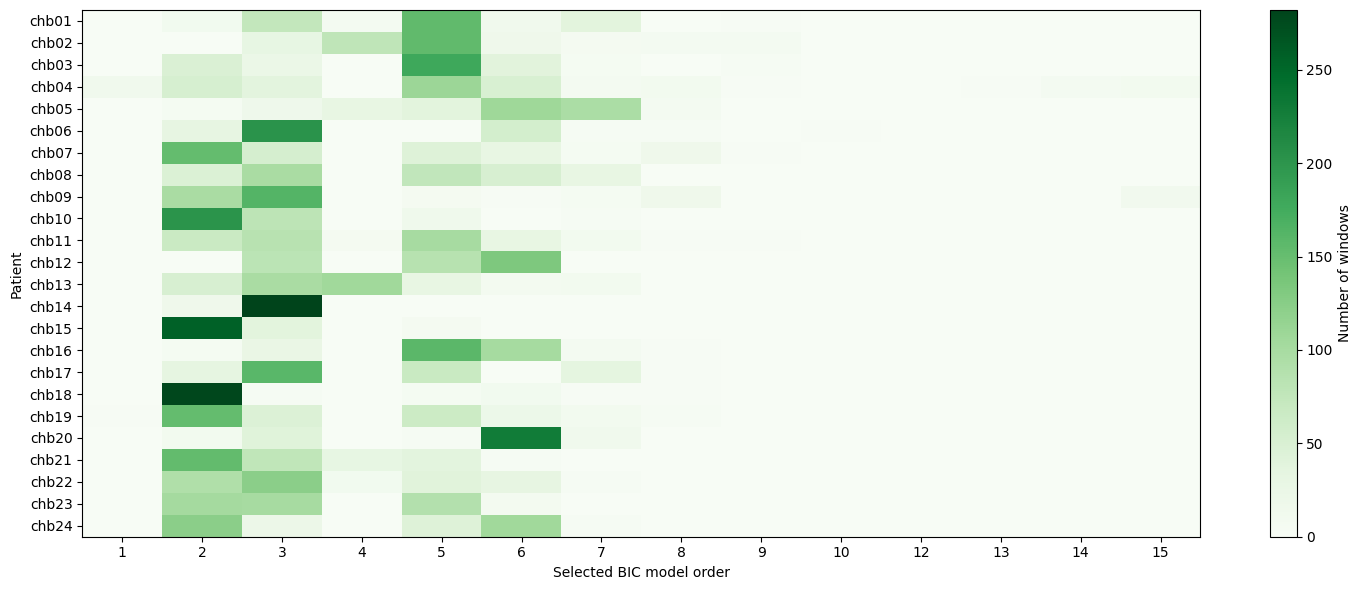

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("var_order_all.csv")

# Count occurrences of each order for each patient
table = (
    df.groupby(["patient", "order"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

plt.figure(figsize=(15,6))
plt.imshow(table, aspect="auto")

plt.xticks(range(len(table.columns)), table.columns)
plt.yticks(range(len(table.index)), table.index)
plt.imshow(table, aspect="auto", cmap="Greens")

plt.xlabel("Selected BIC model order")
plt.ylabel("Patient")

cbar = plt.colorbar()
cbar.set_label("Number of windows")

plt.tight_layout()
plt.show()